# DIFF IN DIFF

In [51]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

In [52]:
# Load datasets
referenda_results = pd.read_csv('../data/processed/cleaned_referenda_results.csv')
party_strength_left = pd.read_csv('../data/processed/party_strength_left_cleaned.csv')
party_strength_right = pd.read_csv('../data/processed/party_strength_right_cleaned.csv')
share_over_64 = pd.read_csv('../data/processed/share_over_64_cleaned.csv')
share_under_20 = pd.read_csv('../data/processed/share_under_20_cleaned.csv')


In [53]:
# Define municipalities and dates for internet voting
early_municipalities = [3213, 3392, 3340, 3297, 3238]
early_date = pd.to_datetime('2023-06-18')
late_municipalities = [3405, 3215, 3251, 3211, 3233, 3352, 3292, 3201, 3374, 3214, 3202, 3407, 3216]
late_date = pd.to_datetime('2024-06-09')

In [54]:
# Create internet voting dummy variable
referenda_results['internet_voting'] = 0
referenda_results['date'] = pd.to_datetime(referenda_results['date'])
referenda_results.loc[(referenda_results['entity_id'].isin(early_municipalities)) & (referenda_results['date'] >= early_date), 'internet_voting'] = 1
referenda_results.loc[(referenda_results['entity_id'].isin(late_municipalities)) & (referenda_results['date'] >= late_date), 'internet_voting'] = 1


In [55]:
# Compute turnouts and store results in a new column
referenda_results['turnout'] = referenda_results['yeas'] + referenda_results['nays'] + referenda_results['empty'] + referenda_results['invalid']
referenda_results['turnout_rate'] = referenda_results['turnout'] / referenda_results['eligible_voters']


In [56]:
# Create a time variable
referenda_results['time_numeric'] = (referenda_results['date'] - referenda_results['date'].min()).dt.days
referenda_results['time_trend'] = referenda_results['time_numeric'] * referenda_results['entity_id'].astype('category').cat.codes

In [57]:
# Melt control variables
party_strength_left = party_strength_left.melt(id_vars=['BFS_NR', 'GEBIET_NAME'], var_name='year', value_name='left_votes')
party_strength_right = party_strength_right.melt(id_vars=['BFS_NR', 'GEBIET_NAME'], var_name='year', value_name='right_votes')
share_over_64 = share_over_64.melt(id_vars=['BFS_NR', 'GEBIET_NAME'], var_name='year', value_name='old_age_dependency')
share_under_20 = share_under_20.melt(id_vars=['BFS_NR', 'GEBIET_NAME'], var_name='year', value_name='youth_dependency')


In [58]:
# Convert year columns to integer (just to be sure)
party_strength_left['year'] = party_strength_left['year'].astype(int)
party_strength_right['year'] = party_strength_right['year'].astype(int)
share_over_64['year'] = share_over_64['year'].astype(int)
share_under_20['year'] = share_under_20['year'].astype(int)


In [59]:
# Create year variable in the main dataset
referenda_results['year'] = referenda_results['date'].dt.year.astype(int)


In [60]:
# Merge control variables with the main dataset
referenda_results = referenda_results.merge(party_strength_left, left_on=['entity_id', 'year'], right_on=['BFS_NR', 'year'], how='left', suffixes=('', '_left'))
referenda_results = referenda_results.merge(party_strength_right, left_on=['entity_id', 'year'], right_on=['BFS_NR', 'year'], how='left', suffixes=('', '_right'))
referenda_results = referenda_results.merge(share_over_64, left_on=['entity_id', 'year'], right_on=['BFS_NR', 'year'], how='left', suffixes=('', '_over64'))
referenda_results = referenda_results.merge(share_under_20, left_on=['entity_id', 'year'], right_on=['BFS_NR', 'year'], how='left', suffixes=('', '_under20'))


In [61]:
# Extract and assign 2022 dependency ratios for 2023 and 2024
dependency_ratios_2022 = referenda_results[referenda_results['year'] == 2022][['entity_id', 'old_age_dependency', 'youth_dependency']].drop_duplicates()
referenda_results = referenda_results.merge(dependency_ratios_2022, on='entity_id', suffixes=('', '_2022'))
referenda_results.loc[referenda_results['year'] >= 2023, 'old_age_dependency'] = referenda_results['old_age_dependency_2022']
referenda_results.loc[referenda_results['year'] >= 2023, 'youth_dependency'] = referenda_results['youth_dependency_2022']
referenda_results = referenda_results.drop(columns=['old_age_dependency_2022', 'youth_dependency_2022'])


In [62]:
# Forward fill and back fill missing values for control variables
referenda_results[['left_votes', 'right_votes', 'old_age_dependency', 'youth_dependency']] = referenda_results[['left_votes', 'right_votes', 'old_age_dependency', 'youth_dependency']].ffill().bfill()

In [63]:
# Model 1: Basic Diff-in-Diff with fixed effects
formula1 = 'turnout_rate ~ internet_voting + C(entity_id) + C(date)'
model1 = ols(formula1, data=referenda_results).fit()
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     504.9
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:53   Log-Likelihood:                 11143.
No. Observations:                6433   AIC:                        -2.209e+04
Df Residuals:                    6336   BIC:                        -2.144e+04
Df Model:                          96                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [64]:
# Model 2: Diff-in-Diff with time trends
formula2 = 'turnout_rate ~ internet_voting + C(entity_id) + C(date) + time_trend'
model2 = ols(formula2, data=referenda_results).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     499.8
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:53   Log-Likelihood:                 11144.
No. Observations:                6433   AIC:                        -2.209e+04
Df Residuals:                    6335   BIC:                        -2.143e+04
Df Model:                          97                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [65]:
# Model 3: Diff-in-Diff with controls
formula3 = 'turnout_rate ~ internet_voting + C(entity_id) + C(date) + time_trend + left_votes + right_votes + old_age_dependency + youth_dependency'
model3 = ols(formula3, data=referenda_results).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     487.7
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:54   Log-Likelihood:                 11191.
No. Observations:                6433   AIC:                        -2.218e+04
Df Residuals:                    6331   BIC:                        -2.149e+04
Df Model:                         101                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

# Staggered treatment effect

In [66]:
# Feature engineering function
def feature_eng(df):  
    df['internet_voting'] = np.where(df['date'] >= early_date, 1, 0)
    df['date_early'] = np.where(df['date'] >= early_date, 1, 0)
    df['date_late'] = np.where(df['date'] >= late_date, 1, 0)
    df['cohort_early'] = np.where(df['entity_id'].isin(early_municipalities), 1.0, 0.0)
    df['cohort_late'] = np.where(df['entity_id'].isin(late_municipalities), 1.0, 0.0)
    return df


In [67]:
# Apply feature engineering
referenda_results_staggered = feature_eng(referenda_results) 


In [68]:
import statsmodels.formula.api as smf #redefine to avoid notation complexity (ols.ols)

In [69]:

# Model 1: Basic Diff-in-Diff with fixed effects (Staggered Treatment)
formula1_staggered = """turnout_rate ~ internet_voting:date_early:cohort_early + internet_voting:date_late:cohort_late + C(entity_id) + C(date)"""
model1_staggered = smf.ols(formula1_staggered, data=referenda_results_staggered).fit(cov_type='HC3')
print(model1_staggered.summary())


                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     722.8
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:54   Log-Likelihood:                 11143.
No. Observations:                6433   AIC:                        -2.209e+04
Df Residuals:                    6335   BIC:                        -2.143e+04
Df Model:                          97                                         
Covariance Type:                  HC3                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [70]:
# Model 2: Diff-in-Diff with time trends (Staggered Treatment)
formula2_staggered = """turnout_rate ~ internet_voting:date_early:cohort_early + internet_voting:date_late:cohort_late + C(entity_id) + C(date) + time_trend"""
model2_staggered = smf.ols(formula2_staggered, data=referenda_results_staggered).fit(cov_type='HC3')
print(model2_staggered.summary())

                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     717.7
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:55   Log-Likelihood:                 11144.
No. Observations:                6433   AIC:                        -2.209e+04
Df Residuals:                    6334   BIC:                        -2.142e+04
Df Model:                          98                                         
Covariance Type:                  HC3                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [71]:
# Model 3: Diff-in-Diff with controls (Staggered Treatment)
formula3_staggered = """turnout_rate ~ internet_voting:date_early:cohort_early + internet_voting:date_late:cohort_late + C(entity_id) + C(date) + time_trend + left_votes + right_votes + old_age_dependency + youth_dependency"""
model3_staggered = smf.ols(formula3_staggered, data=referenda_results_staggered).fit(cov_type='HC3')
print(model3_staggered.summary())

                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     734.5
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:56   Log-Likelihood:                 11191.
No. Observations:                6433   AIC:                        -2.218e+04
Df Residuals:                    6330   BIC:                        -2.148e+04
Df Model:                         102                                         
Covariance Type:                  HC3                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

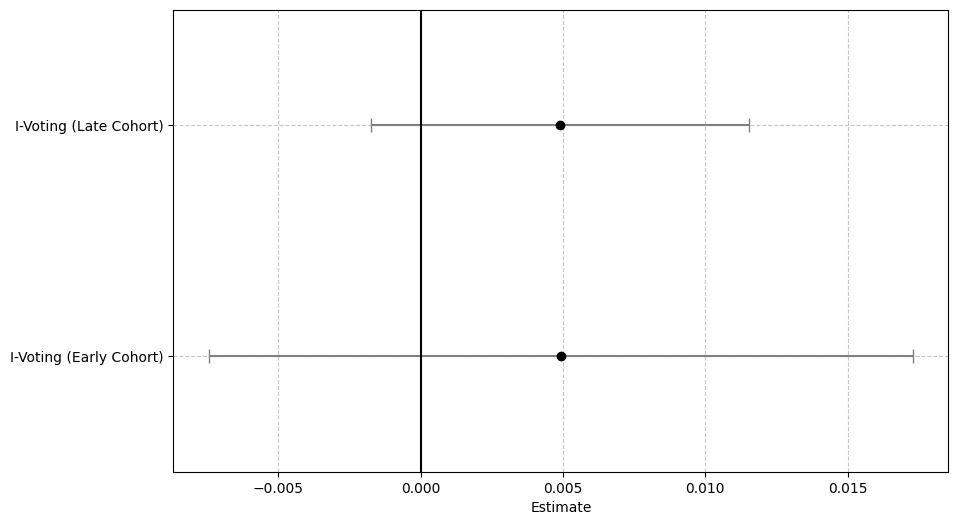

In [72]:
# Extract coefficients and confidence intervals
coefs = model3_staggered.params
conf = model3_staggered.conf_int()
errors = model3_staggered.bse

# Filter coefficients and confidence intervals for internet voting terms
coefs_filtered = coefs[coefs.index.str.contains('internet_voting:')]
conf_filtered = conf.loc[coefs_filtered.index]
errors_filtered = errors.loc[coefs_filtered.index]

# Create a dataframe for plotting
coef_df = pd.DataFrame({
    'coefficient': ['I-Voting (Early Cohort)', 'I-Voting (Late Cohort)'],
    'estimate': coefs_filtered.values,
    'conf.low': conf_filtered[0].values,
    'conf.high': conf_filtered[1].values
})

# Plot 
plt.figure(figsize=(10, 6))
plt.errorbar(coef_df['estimate'], range(len(coef_df)), 
             xerr=[coef_df['estimate'] - coef_df['conf.low'], coef_df['conf.high'] - coef_df['estimate']], 
             fmt='o', color='black', ecolor='gray', capsize=5)
plt.axvline(x=0, color='black', linestyle='solid')
plt.yticks(range(len(coef_df)), coef_df['coefficient'])
plt.xlabel('Estimate')
plt.ylim(-0.5, len(coef_df) - 0.5)  
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [73]:
# Save the plot in results
plt.savefig('../results/coeff_plot.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Low/high turnout

In [74]:
# Calculate the pre-trend average turnout for each municipality
pre_trends_period = referenda_results[referenda_results['date'] < early_date]
average_pre_trend_turnout = pre_trends_period.groupby('entity_id')['turnout_rate'].mean()

# Calculate the median of these average pre-trend turnout rates
median_pre_trend_turnout = average_pre_trend_turnout.median()

# Classify municipalities as low/high turnout based on this median
low_turnout_entities = average_pre_trend_turnout[average_pre_trend_turnout < median_pre_trend_turnout].index
high_turnout_entities = average_pre_trend_turnout[average_pre_trend_turnout >= median_pre_trend_turnout].index

# Ensure all municipalities are classified either as low or high turnout
assert len(low_turnout_entities) + len(high_turnout_entities) == len(average_pre_trend_turnout)

# Define the low_turnout dummy variable consistently across all referenda
referenda_results['low_turnout'] = np.where(referenda_results['entity_id'].isin(low_turnout_entities), 1, 0)
# Define the high_turnout dummy variable consistently across all referenda
referenda_results['high_turnout'] = np.where(referenda_results['entity_id'].isin(high_turnout_entities), 1, 0)

# Filter the dataset to include only low/high turnout municipalities
low_turnout_municipalities = referenda_results[referenda_results['low_turnout'] == 1].copy()
# Filter the dataset to include only high turnout municipalities
high_turnout_municipalities = referenda_results[referenda_results['high_turnout'] == 1].copy()

# Define the feature engineering function
def feature_eng(df):
    df = df.copy()
    df['internet_voting'] = np.where(df['date'] >= early_date, 1, 0)
    df['date_early'] = np.where(df['date'] >= early_date, 1, 0)
    df['date_late'] = np.where(df['date'] >= late_date, 1, 0)
    df['cohort_early'] = np.where(df['entity_id'].isin(early_municipalities), 1.0, 0.0)
    df['cohort_late'] = np.where(df['entity_id'].isin(late_municipalities), 1.0, 0.0)
    return df
    
# Apply feature engineering to the low/high turnout municipalities
low_turnout_municipalities_staggered = feature_eng(low_turnout_municipalities)
# Apply feature engineering to the high turnout municipalities
high_turnout_municipalities_staggered = feature_eng(high_turnout_municipalities)


# Check if the division in low and high is roughly equal
num_low_turnout = referenda_results['low_turnout'].sum()
num_high_turnout = len(referenda_results) - num_low_turnout
print(f"Number of low turnout municipalities ref.: {num_low_turnout}")
print(f"Number of high turnout municipalities ref.: {num_high_turnout}")



Number of low turnout municipalities ref.: 3182
Number of high turnout municipalities ref.: 3251


# Low turnout, Staggered treatment

In [75]:
# Formulas for analysis

# Model 1: Basic Diff-in-Diff with fixed effects (Staggered Treatment)
formula1_staggered_low = 'turnout_rate ~ (internet_voting * low_turnout):date_early:cohort_early + (internet_voting * low_turnout):date_late:cohort_late + C(entity_id) + C(date)'

# Model 2: Diff-in-Diff with time trends (Staggered Treatment)
formula2_staggered_low = 'turnout_rate ~ (internet_voting * low_turnout):date_early:cohort_early + (internet_voting * low_turnout):date_late:cohort_late + C(entity_id) + C(date) + time_trend'

# Model 3: Diff-in-Diff with controls (Staggered Treatment)
formula3_staggered_low = 'turnout_rate ~ (internet_voting * low_turnout):date_early:cohort_early + (internet_voting * low_turnout):date_late:cohort_late + C(entity_id) + C(date) + time_trend + left_votes + right_votes + old_age_dependency + youth_dependency'


In [76]:
# Model 1: Basic Diff-in-Diff with fixed effects (Staggered Treatment, low turnout)
model1_staggered_low = smf.ols(formula1_staggered_low, data=referenda_results_staggered).fit(cov_type='HC3')
print(model1_staggered_low.summary())


                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     709.9
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:57   Log-Likelihood:                 11146.
No. Observations:                6433   AIC:                        -2.209e+04
Df Residuals:                    6333   BIC:                        -2.141e+04
Df Model:                          99                                         
Covariance Type:                  HC3                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 101, but rank is 99
  warnings.warn('covariance of constraints does not have full '


In [77]:
# Model 2: Diff-in-Diff with time trends (Staggered Treatment, low turnout)
model2_staggered_low = smf.ols(formula2_staggered_low, data=referenda_results_staggered).fit(cov_type='HC3')
print(model2_staggered_low.summary())

                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     705.6
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:57   Log-Likelihood:                 11147.
No. Observations:                6433   AIC:                        -2.209e+04
Df Residuals:                    6332   BIC:                        -2.141e+04
Df Model:                         100                                         
Covariance Type:                  HC3                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 102, but rank is 100
  warnings.warn('covariance of constraints does not have full '


In [78]:
# Model 3: Diff-in-Diff with controls (Staggered Treatment, low turnout)
model3_staggered_low = smf.ols(formula3_staggered_low, data=referenda_results_staggered).fit(cov_type='HC3')
print(model3_staggered_low.summary())

                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     722.7
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:58   Log-Likelihood:                 11194.
No. Observations:                6433   AIC:                        -2.218e+04
Df Residuals:                    6328   BIC:                        -2.147e+04
Df Model:                         104                                         
Covariance Type:                  HC3                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 106, but rank is 104
  warnings.warn('covariance of constraints does not have full '


# High Turnout, Staggered Treatment

In [79]:
# Formulas for analysis

# Model 1: Basic Diff-in-Diff with fixed effects (Staggered Treatment)
formula1_staggered_high = 'turnout_rate ~ (internet_voting * high_turnout):date_early:cohort_early + (internet_voting * high_turnout):date_late:cohort_late + C(entity_id) + C(date)'

# Model 2: Diff-in-Diff with time trends (Staggered Treatment)
formula2_staggered_high = 'turnout_rate ~ (internet_voting * high_turnout):date_early:cohort_early + (internet_voting * high_turnout):date_late:cohort_late + C(entity_id) + C(date) + time_trend'

# Model 3: Diff-in-Diff with controls (Staggered Treatment)
formula3_staggered_high = 'turnout_rate ~ (internet_voting * high_turnout):date_early:cohort_early + (internet_voting * high_turnout):date_late:cohort_late + C(entity_id) + C(date) + time_trend + left_votes + right_votes + old_age_dependency + youth_dependency'

In [80]:
# Model 1: Basic Diff-in-Diff with fixed effects (Staggered Treatment, high turnout)
model1_staggered_high = smf.ols(formula1_staggered_high, data=referenda_results_staggered).fit(cov_type='HC3')
print(model1_staggered_high.summary())


                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     709.9
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:36:59   Log-Likelihood:                 11146.
No. Observations:                6433   AIC:                        -2.209e+04
Df Residuals:                    6333   BIC:                        -2.141e+04
Df Model:                          99                                         
Covariance Type:                  HC3                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 101, but rank is 99
  warnings.warn('covariance of constraints does not have full '


In [81]:
# Model 2: Diff-in-Diff with time trends (Staggered Treatment, high turnout)
model2_staggered_high = smf.ols(formula2_staggered_high, data=referenda_results_staggered).fit(cov_type='HC3')
print(model2_staggered_high.summary())

                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     705.6
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:37:00   Log-Likelihood:                 11147.
No. Observations:                6433   AIC:                        -2.209e+04
Df Residuals:                    6332   BIC:                        -2.141e+04
Df Model:                         100                                         
Covariance Type:                  HC3                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 102, but rank is 100
  warnings.warn('covariance of constraints does not have full '


In [82]:
# Model 3: Diff-in-Diff with controls (Staggered Treatment, high turnout)
model3_staggered_high = smf.ols(formula3_staggered_high, data=referenda_results_staggered).fit(cov_type='HC3')
print(model3_staggered_high.summary())

                            OLS Regression Results                            
Dep. Variable:           turnout_rate   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     722.7
Date:                Sat, 20 Jul 2024   Prob (F-statistic):               0.00
Time:                        17:37:00   Log-Likelihood:                 11194.
No. Observations:                6433   AIC:                        -2.218e+04
Df Residuals:                    6328   BIC:                        -2.147e+04
Df Model:                         104                                         
Covariance Type:                  HC3                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 106, but rank is 104
  warnings.warn('covariance of constraints does not have full '
